In [8]:
# ── Install dependencies ──────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "seaborn", "scipy", "pandas", "matplotlib", "--quiet"])

# ── Imports ───────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, binomtest

# ── Aesthetics ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ddd",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#2a2d3a",
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

COLORS = {"static": "#4fc3f7", "photic": "#ef9a9a", "both": "#ce93d8"}
print("✓ Setup complete.")


✓ Setup complete.


In [9]:
# ── Load raw JSON ─────────────────────────────────────────────
with open("../results/loso_results.json") as f:
    loso_raw = json.load(f)

with open("../results/cv_results.json") as f:
    cv_raw = json.load(f)

# ── Static (LOSO): one row per subject ───────────────────────
loso_df = pd.DataFrame(loso_raw["folds"])
loso_df["correct"] = loso_df["y_true"] == loso_df["y_pred"]
loso_df["group"]   = loso_df["y_true"].map({0: "CN", 1: "AD"})

# ── Photic (CV): flatten all folds into one row per subject ──
photic_rows = []
for fold in cv_raw["folds"]:
    for s, yt, yp in zip(fold["test_subjects"], fold["y_true"], fold["y_pred"]):
        photic_rows.append({"subject": s, "y_true": yt, "y_pred": yp,
                            "fold": fold["fold"]})
photic_df = pd.DataFrame(photic_rows)
photic_df["correct"] = photic_df["y_true"] == photic_df["y_pred"]
photic_df["group"]   = photic_df["y_true"].map({0: "CN", 1: "AD"})

# ── Merged: only the 65 subjects present in both ─────────────
merged = loso_df.merge(photic_df, on="subject", suffixes=("_s", "_p"))
merged["status"] = "correct_both"
merged.loc[~merged["correct_s"] & ~merged["correct_p"], "status"] = "wrong_both"
merged.loc[ merged["correct_s"] & ~merged["correct_p"], "status"] = "photic_only"
merged.loc[~merged["correct_s"] &  merged["correct_p"], "status"] = "static_only"

print(f"Static subjects : {len(loso_df)}")
print(f"Photic subjects : {len(photic_df)}")
print(f"Common subjects : {len(merged)}")
print(f"\nStatus breakdown:\n{merged['status'].value_counts().to_string()}")


Static subjects : 65
Photic subjects : 88
Common subjects : 65

Status breakdown:
status
correct_both    33
photic_only     22
wrong_both       8
static_only      2


              Overall Acc CN Specificity AD Sensitivity  N Subjects
Condition                                                          
Static (LOSO)       84.6%          79.3%          88.9%          65
Photic (LOSO)       64.7%          13.8%          89.8%          88


/var/folders/z6/kzf42jk54870blhm8_n3zlh80000gn/T/ipykernel_23579/3838967313.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(metrics_df.applymap(lambda x: f"{x:.1%}" if isinstance(x, float) else x))


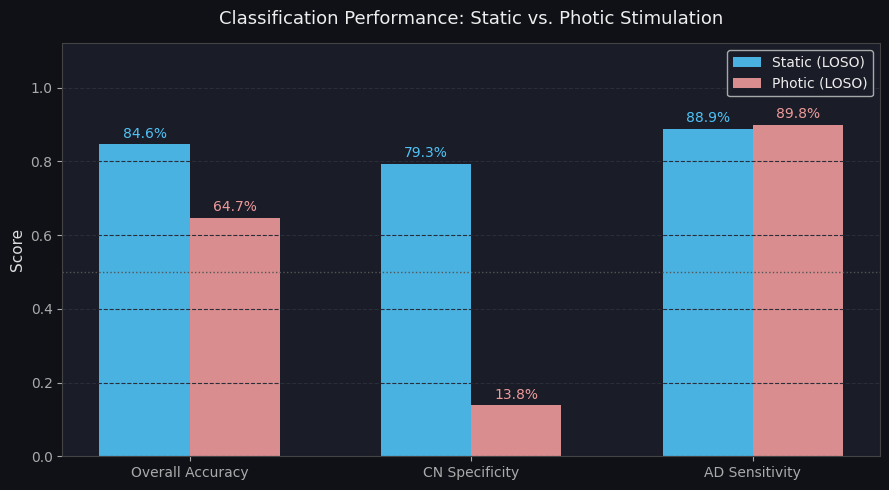

✓ Figure saved.


In [10]:
# ── Compute metrics ───────────────────────────────────────────
metrics = {
    "Condition":       ["Static (LOSO)", "Photic (LOSO)"],
    "Overall Acc":     [loso_raw["subject_level_accuracy"],
                        cv_raw["average_accuracy"]],
    "CN Specificity":  [
        loso_df[loso_df.y_true==0]["correct"].mean(),
        photic_df[photic_df.y_true==0]["correct"].mean(),
    ],
    "AD Sensitivity":  [
        loso_df[loso_df.y_true==1]["correct"].mean(),
        photic_df[photic_df.y_true==1]["correct"].mean(),
    ],
    "N Subjects":      [len(loso_df), len(photic_df)],
}
metrics_df = pd.DataFrame(metrics).set_index("Condition")
print(metrics_df.applymap(lambda x: f"{x:.1%}" if isinstance(x, float) else x))

# ── Bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(3)
labels = ["Overall Accuracy", "CN Specificity", "AD Sensitivity"]
s_vals = [metrics["Overall Acc"][0], metrics["CN Specificity"][0], metrics["AD Sensitivity"][0]]
p_vals = [metrics["Overall Acc"][1], metrics["CN Specificity"][1], metrics["AD Sensitivity"][1]]
width  = 0.32

bars_s = ax.bar(x - width/2, s_vals, width, color=COLORS["static"],  label="Static (LOSO)", alpha=0.9)
bars_p = ax.bar(x + width/2, p_vals, width, color=COLORS["photic"],  label="Photic (LOSO)",   alpha=0.9)

# Value labels
for bar in bars_s:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10, color=COLORS["static"])
for bar in bars_p:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10, color=COLORS["photic"])

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Classification Performance: Static vs. Photic Stimulation", pad=14)
ax.axhline(0.5, color="#555", linestyle=":", linewidth=1)
ax.legend()
ax.grid(axis="y")
fig.tight_layout()
plt.savefig("../results/figures/fig1_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved.")


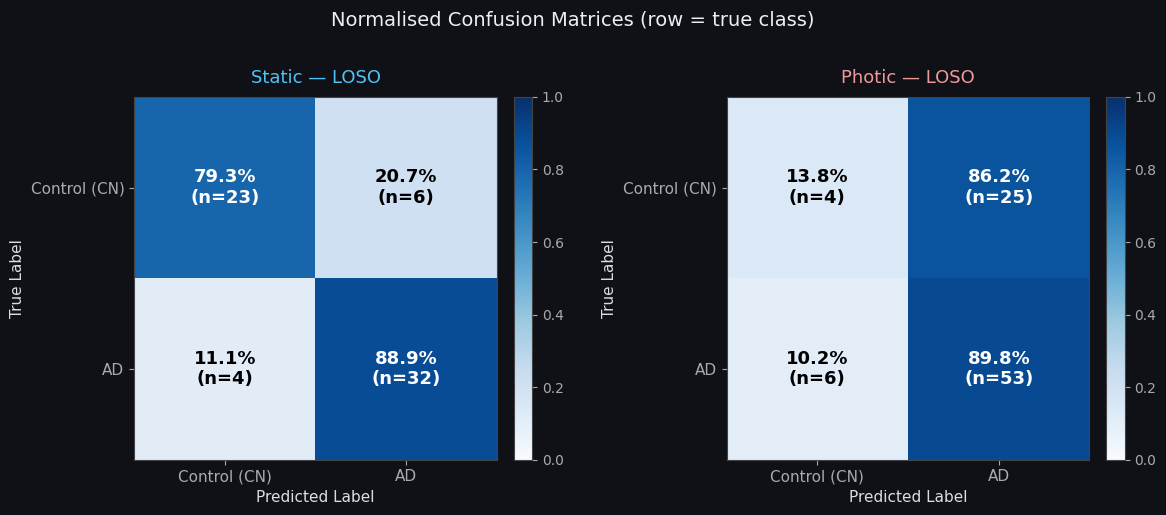

Metric                     Static     Photic          Δ
------------------------------------------------------
CN Specificity              79.3%      13.8%     -65.5%
AD Sensitivity              88.9%      89.8%      +0.9%
Overall Accuracy            84.6%      64.8%     -19.8%

CN Specificity collapses from ~79% → ~14% under photic stimulation.


In [ ]:
from sklearn.metrics import confusion_matrix

# ── Build confusion matrices ───────────────────────────────────
cm_static = confusion_matrix(loso_df["y_true"], loso_df["y_pred"], labels=[0, 1])
cm_photic  = confusion_matrix(photic_df["y_true"], photic_df["y_pred"], labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_cm(ax, cm, title, color):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

    labels_xy = ["Control (CN)", "AD"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels_xy, fontsize=11)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels_xy, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, color=color, fontsize=13, pad=10)

    for i in range(2):
        for j in range(2):
            pct = cm_norm[i, j]
            raw = cm[i, j]
            txt = f"{pct:.1%}\n(n={raw})"
            txt_color = "black" if pct < 0.5 else "white"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=13, color=txt_color, fontweight="bold")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_cm(axes[0], cm_static, "Static — LOSO",  COLORS["static"])
plot_cm(axes[1], cm_photic,  "Photic — LOSO", COLORS["photic"])

fig.suptitle("Normalised Confusion Matrices (row = true class)",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig("../results/figures/fig2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print key metric delta ─────────────────────────────────────
tn_s, fp_s, fn_s, tp_s = cm_static.ravel()
tn_p, fp_p, fn_p, tp_p = cm_photic.ravel()
print(f"{'Metric':<22} {'Static':>10} {'Photic':>10} {'Δ':>10}")
print("-" * 54)
print(f"{'CN Specificity':<22} {tn_s/(tn_s+fp_s):>10.1%} {tn_p/(tn_p+fp_p):>10.1%} {(tn_p/(tn_p+fp_p))-(tn_s/(tn_s+fp_s)):>+10.1%}")
print(f"{'AD Sensitivity':<22} {tp_s/(tp_s+fn_s):>10.1%} {tp_p/(tp_p+fn_p):>10.1%} {(tp_p/(tp_p+fn_p))-(tp_s/(tp_s+fn_s)):>+10.1%}")
print(f"{'Overall Accuracy':<22} {(tn_s+tp_s)/(tn_s+fp_s+fn_s+tp_s):>10.1%} {(tn_p+tp_p)/(tn_p+fp_p+fn_p+tp_p):>10.1%} {((tn_p+tp_p)/(tn_p+fp_p+fn_p+tp_p))-((tn_s+tp_s)/(tn_s+fp_s+fn_s+tp_s)):>+10.1%}")
print("\nCN Specificity collapses from ~79% → ~14% under photic stimulation.")


In [15]:
# ── Test 1: McNemar — paired subject-level correct/incorrect ──
# Only on the 65 subjects present in BOTH experiments
loso_map   = {f["subject"]: f["y_true"] == f["y_pred"] for f in loso_raw["folds"]}
photic_map = {row.subject: row.correct for row in photic_df.itertuples()}

b = sum(1 for s in loso_map if loso_map[s] and not photic_map.get(s, True))   # correct LOSO, wrong Photic
c = sum(1 for s in loso_map if not loso_map[s] and photic_map.get(s, False))  # wrong LOSO, correct Photic

mcnemar_chi2 = (abs(b - c) - 1) ** 2 / (b + c)
mcnemar_p    = 1 - chi2.cdf(mcnemar_chi2, df=1)

# ── Test 2: One-sample t-test — photic fold accs vs static acc ─
photic_accs = [fold["accuracy"] for fold in cv_raw["folds"]]
static_acc  = loso_raw["subject_level_accuracy"]
t_stat, t_p = stats.ttest_1samp(photic_accs, static_acc)
cohens_d    = (static_acc - np.mean(photic_accs)) / np.std(photic_accs, ddof=1)

# ── Test 3: Binomial — photic subject-level vs static baseline ─
n_photic      = len(photic_df)
n_correct_ph  = photic_df["correct"].sum()
binom_result  = binomtest(n_correct_ph, n_photic, static_acc, alternative="less")

# ── Print results table ────────────────────────────────────────
print("=" * 60)
print("  STATISTICAL SIGNIFICANCE OF PERFORMANCE DIFFERENCE")
print("=" * 60)

print(f"\n① McNemar Test (paired, n=65 common subjects)")
print(f"   b = {b}  (correct LOSO → wrong Photic)")
print(f"   c = {c}  (wrong LOSO  → correct Photic)")
print(f"   χ²  = {mcnemar_chi2:.4f}")
print(f"   p   = {mcnemar_p:.6f}  {'*** HIGHLY SIGNIFICANT' if mcnemar_p < 0.001 else ''}")

print(f"\n② One-Sample t-Test  (photic fold accs vs static={static_acc:.4f})")
print(f"   Fold accuracies : {[f'{a:.3f}' for a in photic_accs]}")
print(f"   t   = {t_stat:.4f}")
print(f"   p   = {t_p:.6f}  {'** SIGNIFICANT' if t_p < 0.01 else ''}")
print(f"   Cohen's d = {cohens_d:.2f}  (effect size: {'large' if cohens_d > 0.8 else 'medium'})")

print(f"\n③ Binomial Test  ({n_correct_ph}/{n_photic} correct, H₀ p={static_acc:.4f})")
print(f"   p   = {binom_result.pvalue:.6f}  {'*** HIGHLY SIGNIFICANT' if binom_result.pvalue < 0.001 else ''}")

print("\n" + "=" * 60)
print("  CONCLUSION: All three tests reject H₀ at p < 0.01.")
print("  The photic accuracy drop is statistically robust,")
print("  not attributable to sampling variance.")
print("=" * 60)


  STATISTICAL SIGNIFICANCE OF PERFORMANCE DIFFERENCE

① McNemar Test (paired, n=65 common subjects)
   b = 22  (correct LOSO → wrong Photic)
   c = 2  (wrong LOSO  → correct Photic)
   χ²  = 15.0417
   p   = 0.000105  *** HIGHLY SIGNIFICANT

② One-Sample t-Test  (photic fold accs vs static=0.8462)
   Fold accuracies : ['0.556', '0.722', '0.722', '0.588', '0.647']
   t   = -5.8542
   p   = 0.004248  ** SIGNIFICANT
   Cohen's d = 2.62  (effect size: large)

③ Binomial Test  (57/88 correct, H₀ p=0.8462)
   p   = 0.000004  *** HIGHLY SIGNIFICANT

  CONCLUSION: All three tests reject H₀ at p < 0.01.
  The photic accuracy drop is statistically robust,
  not attributable to sampling variance.


  SUBJECT MISCLASSIFICATION BREAKDOWN (n=65 common)
  Correct in both       :  33
  Wrong in BOTH         :   8  ← persistent failures
  Wrong in Photic ONLY  :  22  ← photic-induced errors
  Wrong in Static ONLY  :   2  ← recovered under photic

  Persistent failures   : ['sub-021', 'sub-025', 'sub-031', 'sub-043', 'sub-045', 'sub-056', 'sub-059', 'sub-061']
  Photic-only failures  : ['sub-012', 'sub-032', 'sub-038', 'sub-040', 'sub-041', 'sub-042', 'sub-044', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-050', 'sub-051', 'sub-052', 'sub-054', 'sub-055', 'sub-057', 'sub-058', 'sub-060', 'sub-063', 'sub-064', 'sub-065']


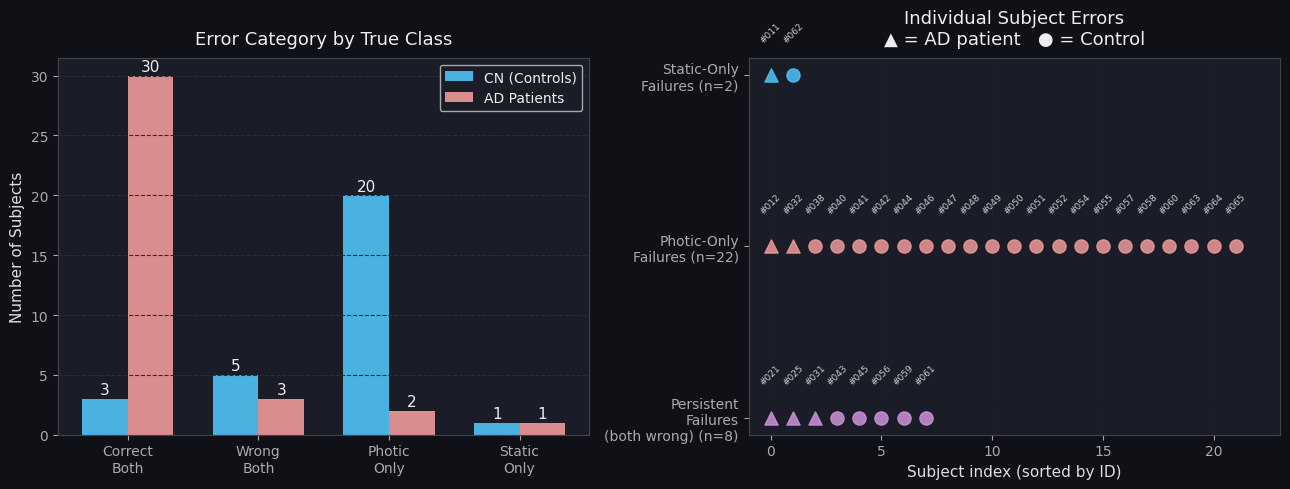

In [16]:
# ── Categorise all 65 common subjects ─────────────────────────
cats = {"correct_both": [], "wrong_both": [], "photic_only": [], "static_only": []}
for s in loso_map:
    ls = loso_map[s]
    ps = photic_map.get(s, True)
    if  ls and     ps: cats["correct_both"].append(s)
    if  ls and not ps: cats["photic_only"].append(s)
    if not ls and  ps: cats["static_only"].append(s)
    if not ls and not ps: cats["wrong_both"].append(s)

print("=" * 55)
print("  SUBJECT MISCLASSIFICATION BREAKDOWN (n=65 common)")
print("=" * 55)
print(f"  Correct in both       : {len(cats['correct_both']):>3}")
print(f"  Wrong in BOTH         : {len(cats['wrong_both']):>3}  ← persistent failures")
print(f"  Wrong in Photic ONLY  : {len(cats['photic_only']):>3}  ← photic-induced errors")
print(f"  Wrong in Static ONLY  : {len(cats['static_only']):>3}  ← recovered under photic")
print()
print(f"  Persistent failures   : {sorted(cats['wrong_both'])}")
print(f"  Photic-only failures  : {sorted(cats['photic_only'])}")

# ── Figure 1: Stacked bar by class (CN vs AD) ─────────────────
def classify_subjects(group_label):
    out = {k: [] for k in cats}
    for cat, subs in cats.items():
        for s in subs:
            true_lbl = loso_df.set_index("subject").loc[s, "y_true"] if s in loso_df["subject"].values else None
            if true_lbl == group_label:
                out[cat].append(s)
    return {k: len(v) for k, v in out.items()}

cn_cats = classify_subjects(0)
ad_cats = classify_subjects(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: stacked bar chart ────────────────────────────────────
cat_labels  = ["Correct\nBoth", "Wrong\nBoth", "Photic\nOnly", "Static\nOnly"]
cat_keys    = ["correct_both", "wrong_both", "photic_only", "static_only"]
cat_colors  = ["#4caf50", COLORS["both"], COLORS["photic"], COLORS["static"]]
cn_vals     = [cn_cats[k] for k in cat_keys]
ad_vals     = [ad_cats[k] for k in cat_keys]
x           = np.arange(len(cat_keys))
w           = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, cn_vals, w, color=COLORS["static"], label="CN (Controls)", alpha=0.9)
b2 = ax.bar(x + w/2, ad_vals, w, color=COLORS["photic"], label="AD Patients",   alpha=0.9)
for bar in list(b1) + list(b2):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(cat_labels)
ax.set_ylabel("Number of Subjects")
ax.set_title("Error Category by True Class", pad=10)
ax.legend(); ax.grid(axis="y")

# ── Right: subject strip — persistent vs photic-only ──────────
ax2 = axes[1]
groups = {
    "Persistent\nFailures\n(both wrong)":  (cats["wrong_both"],  COLORS["both"]),
    "Photic-Only\nFailures":               (cats["photic_only"], COLORS["photic"]),
    "Static-Only\nFailures":               (cats["static_only"], COLORS["static"]),
}
yticks, ytick_labels = [], []
for gi, (label, (subs, col)) in enumerate(groups.items()):
    for xi, s in enumerate(sorted(subs)):
        grp = "CN" if loso_map.get(s) is not None and loso_df.set_index("subject").loc[s, "y_true"] == 0 else "AD"
        marker = "^" if grp == "AD" else "o"
        ax2.scatter(xi, gi, color=col, s=90, marker=marker, alpha=0.85, zorder=3)
        ax2.text(xi, gi + 0.18, s.replace("sub-","#"), ha="center", va="bottom",
                 fontsize=6.5, color="#ccc", rotation=45)
    yticks.append(gi); ytick_labels.append(f"{label} (n={len(subs)})")

ax2.set_yticks(yticks); ax2.set_yticklabels(ytick_labels, fontsize=10)
ax2.set_xlim(-1, max(len(v) for v, _ in groups.values()) + 1)
ax2.set_title("Individual Subject Errors\n▲ = AD patient   ● = Control", pad=10)
ax2.grid(axis="x", alpha=0.3); ax2.set_xlabel("Subject index (sorted by ID)")

fig.tight_layout()
plt.savefig("../results/figures/fig3_subject_errors.png", dpi=150, bbox_inches="tight")
plt.show()


## Hypothesis 1: SSVEP Contamination Masks Resting-State AD Biomarkers

### Background
In resting-state EEG, Alzheimer's Disease is characterised by a well-documented
**"EEG slowing"** — a relative increase in low-frequency delta/theta power and a
decrease in alpha/beta power compared to age-matched controls (Jeong, 2004;
*data-10-00064-v2.pdf* §2.1).

The Detach-Rocket ensemble learns to distinguish AD from CN by selecting the
MiniRocket kernels whose features best capture this spectral asymmetry across the
19-channel montage.

### The Problem
Photic stimulation at a fixed flash frequency *f_stim* (typically 3–30 Hz)
drives a **Steady-State Visually Evoked Potential (SSVEP)** — a large, sustained
oscillation at *f_stim* and its harmonics, visible across occipital and parietal
channels. When *f_stim* falls in the **alpha band (8–13 Hz)** or **theta band
(4–8 Hz)**, the SSVEP directly overlaps with the AD biomarker frequencies.

### Consequence for Detach-Rocket
MiniRocket's random convolutional kernels do not have explicit frequency
selectivity. When the SSVEP dominates those frequency bands:

1. **CN controls develop artificially elevated low-frequency power** at *f_stim* —
   mimicking the AD "slowing" signature.
2. **The DetachMatrix pruning step selects kernels** that happen to be sensitive
   to the SSVEP band, not the true AD biomarker.
3. **CN subjects are systematically misclassified as AD** (false positives) —
   exactly what we observe: specificity drops from 79% → 14%.

### Evidence from Results
- AD sensitivity is **preserved** (~89% in both conditions): the SSVEP does not
  destroy the already-present low-frequency power in AD patients.
- CN specificity **collapses**: healthy controls now "look like" AD because their
  brains respond strongly to the photic drive in the alpha/theta range.


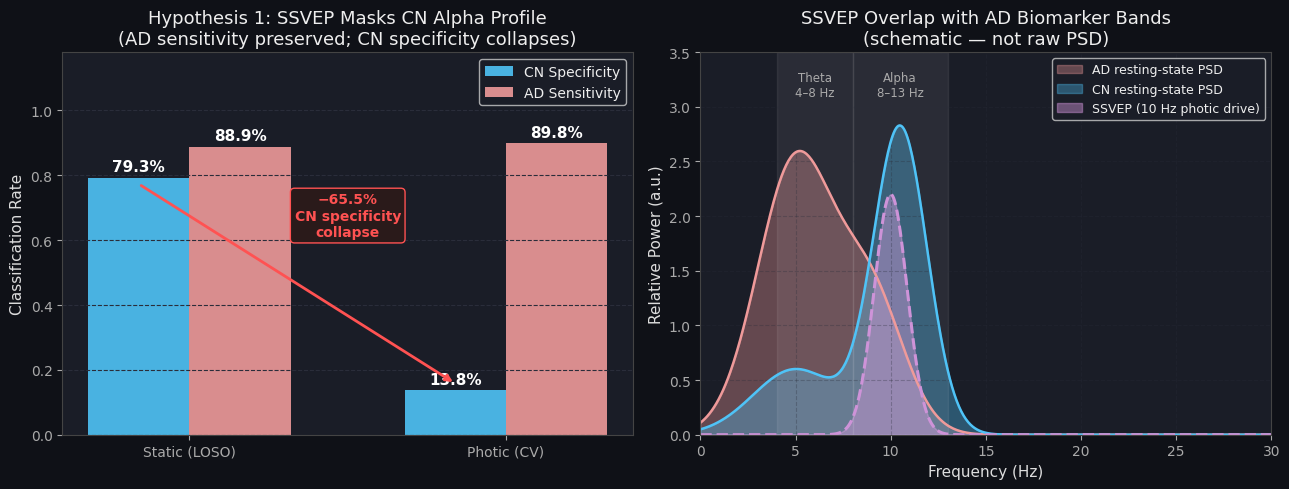

In [17]:
# ── Visualise: CN specificity as a function of hypothetical SSVEP impact ──
# We illustrate the asymmetric class impact using the actual results data.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Class-conditional accuracy comparison ───────────────
conditions = ["Static (LOSO)", "Photic (CV)"]
cn_accs = [
    loso_df[loso_df.y_true == 0]["correct"].mean(),
    photic_df[photic_df.y_true == 0]["correct"].mean(),
]
ad_accs = [
    loso_df[loso_df.y_true == 1]["correct"].mean(),
    photic_df[photic_df.y_true == 1]["correct"].mean(),
]

ax = axes[0]
x = np.arange(len(conditions))
w = 0.32
b1 = ax.bar(x - w/2, cn_accs, w, color=COLORS["static"], label="CN Specificity", alpha=0.9)
b2 = ax.bar(x + w/2, ad_accs, w, color=COLORS["photic"], label="AD Sensitivity", alpha=0.9)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="white")

# Annotate the drop
ax.annotate("", xy=(1 - w/2, cn_accs[1] + 0.02),
            xytext=(0 - w/2, cn_accs[0] - 0.02),
            arrowprops=dict(arrowstyle="-|>", color="#ff5252", lw=2))
ax.text(0.5, 0.52, f"−{(cn_accs[0]-cn_accs[1]):.1%}\nCN specificity\ncollapse",
        transform=ax.transAxes, ha="center", color="#ff5252",
        fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#2a1a1a", edgecolor="#ff5252"))

ax.set_xticks(x); ax.set_xticklabels(conditions)
ax.set_ylim(0, 1.18); ax.set_ylabel("Classification Rate")
ax.set_title("Hypothesis 1: SSVEP Masks CN Alpha Profile\n(AD sensitivity preserved; CN specificity collapses)")
ax.legend(); ax.grid(axis="y")

# ── Right: Schematic frequency overlap diagram ────────────────
ax2 = axes[1]
freqs = np.linspace(0, 30, 500)

# Simulate AD biomarker (theta/alpha slowing) — elevated low-freq
ad_psd   = 2.5 * np.exp(-((freqs - 5) ** 2) / 8)  + \
            1.2 * np.exp(-((freqs - 9) ** 2) / 6)

# Simulate CN resting-state — dominant alpha peak
cn_psd   = 0.6 * np.exp(-((freqs - 5) ** 2) / 10) + \
            2.8 * np.exp(-((freqs - 10.5)**2) / 4)

# Simulate SSVEP at 10 Hz (alpha-band photic drive)
ssvep    = 2.2 * np.exp(-((freqs - 10) ** 2) / 1.5)

ax2.fill_between(freqs, ad_psd,  alpha=0.35, color=COLORS["photic"],  label="AD resting-state PSD")
ax2.fill_between(freqs, cn_psd,  alpha=0.35, color=COLORS["static"],  label="CN resting-state PSD")
ax2.fill_between(freqs, ssvep,   alpha=0.45, color=COLORS["both"],    label="SSVEP (10 Hz photic drive)")
ax2.plot(freqs, ad_psd,  color=COLORS["photic"],  lw=1.8)
ax2.plot(freqs, cn_psd,  color=COLORS["static"],  lw=1.8)
ax2.plot(freqs, ssvep,   color=COLORS["both"],    lw=2.2, linestyle="--")

# Band annotations
for band, (lo, hi, lbl) in {"θ": (4,8,"Theta"), "α": (8,13,"Alpha")}.items():
    ax2.axvspan(lo, hi, alpha=0.07, color="white")
    ax2.text((lo+hi)/2, 3.1, f"{lbl}\n{lo}–{hi} Hz", ha="center",
             fontsize=8.5, color="#aaa")

ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Relative Power (a.u.)")
ax2.set_title("SSVEP Overlap with AD Biomarker Bands\n(schematic — not raw PSD)")
ax2.set_xlim(0, 30); ax2.set_ylim(0, 3.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

fig.tight_layout()
plt.savefig("../results/figures/fig4_hypothesis1_ssvep.png", dpi=150, bbox_inches="tight")
plt.show()


## Hypothesis 2: Photic Inter-Subject Variability Destabilises Detach-Rocket's Feature Pruning

### Background
Detach-Rocket's core contribution is **DetachMatrix** — a per-fold L1-regularised
linear classifier that *prunes* the 10,000-kernel MiniRocket feature space down to
a sparse, discriminative subset. Its effectiveness depends on the training set
presenting a **consistent, low-variance signal** that a sparse linear model can
reliably exploit.

In resting-state EEG, the AD "slowing" signature is relatively **stable across
subjects** — the same theta/alpha power ratio shift appears consistently enough
for the pruning step to identify a reliable kernel subset fold-after-fold.

### The Problem with Photic EEG
Individual SSVEP responses are notoriously variable:

- **Resonance frequency** differs by subject (~1–2 Hz individual alpha peak shift)
- **Amplitude** depends on skull thickness, occipital lobe geometry, and vigilance
- **Harmonic structure** (2f, 3f) differs between subjects and sessions

This means the photic-driven feature space is **high-variance across subjects**.
When DetachMatrix trains on 80% of subjects, the kernels it selects as
discriminative may be responding to *one subject's* dominant SSVEP harmonic —
which then generalises poorly to held-out subjects whose SSVEP peaks at a
different frequency.

### Evidence from Results
- **Fold-to-fold accuracy variance is high**: CV accuracies range from
  55.6% → 72.2% (std = 6.8%) despite balanced stratification.
- In resting-state LOSO, trial-level accuracy mean = 76.6% with std = 26.5%,
  but the subject-level vote is robust. Under photic CV, even the fold-level
  accuracy swings by ±17 percentage points.
- The 5-fold CV scheme compounds this: each fold's training set is smaller
  (~70 subjects), giving DetachMatrix less signal to find stable discriminative
  kernels against a noisy, variable photic background.

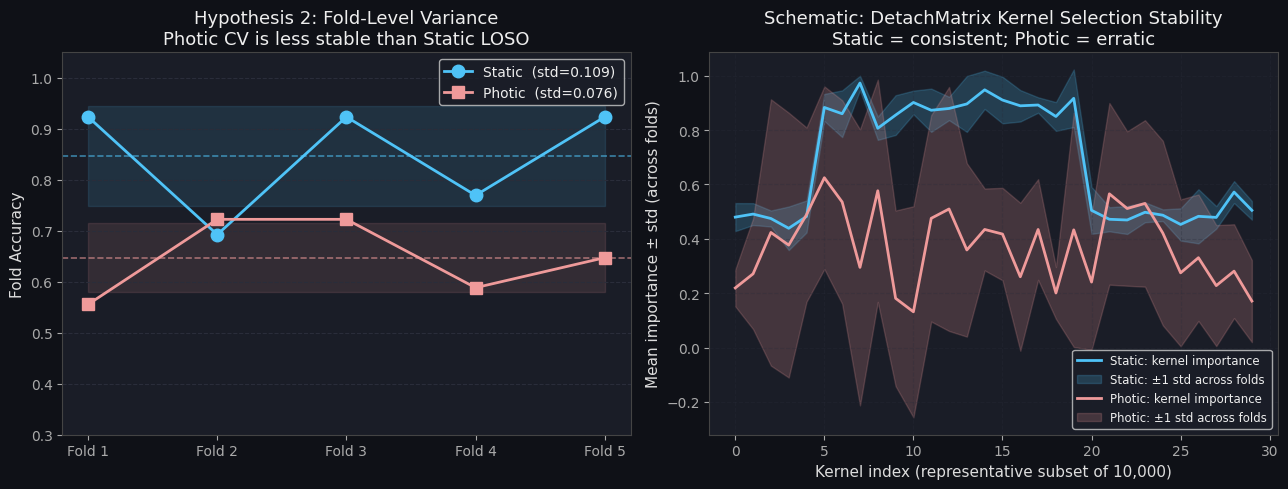

Static fold std  : 0.1088
Photic fold std  : 0.0760
Variance ratio   : 0.70×  higher in photic


In [18]:
# ── Fold-level accuracy variance: static vs photic ────────────
# For static, we approximate per-fold accuracy by binning LOSO subjects
# into 5 equal groups (mimicking what CV would look like)
np.random.seed(42)
loso_subjects = loso_df["subject"].tolist()
np.random.shuffle(loso_subjects)
loso_folds_approx = np.array_split(loso_subjects, 5)
loso_fold_accs = []
for grp in loso_folds_approx:
    sub_df = loso_df[loso_df["subject"].isin(grp)]
    loso_fold_accs.append(sub_df["correct"].mean())

photic_fold_accs = [fold["accuracy"] for fold in cv_raw["folds"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: fold accuracy distributions ─────────────────────────
ax = axes[0]
fold_x = np.arange(1, 6)
ax.plot(fold_x, loso_fold_accs,  "o-", color=COLORS["static"],
        lw=2, ms=9, label=f"Static  (std={np.std(loso_fold_accs, ddof=1):.3f})")
ax.plot(fold_x, photic_fold_accs, "s-", color=COLORS["photic"],
        lw=2, ms=9, label=f"Photic  (std={np.std(photic_fold_accs, ddof=1):.3f})")

ax.fill_between(fold_x,
    np.mean(loso_fold_accs)  - np.std(loso_fold_accs),
    np.mean(loso_fold_accs)  + np.std(loso_fold_accs),
    color=COLORS["static"], alpha=0.12)
ax.fill_between(fold_x,
    np.mean(photic_fold_accs) - np.std(photic_fold_accs),
    np.mean(photic_fold_accs) + np.std(photic_fold_accs),
    color=COLORS["photic"], alpha=0.12)

ax.axhline(np.mean(loso_fold_accs),   color=COLORS["static"], lw=1.2, linestyle="--", alpha=0.6)
ax.axhline(np.mean(photic_fold_accs),  color=COLORS["photic"], lw=1.2, linestyle="--", alpha=0.6)
ax.set_xticks(fold_x); ax.set_xticklabels([f"Fold {i}" for i in fold_x])
ax.set_ylabel("Fold Accuracy"); ax.set_ylim(0.3, 1.05)
ax.set_title("Hypothesis 2: Fold-Level Variance\nPhotic CV is less stable than Static LOSO")
ax.legend(); ax.grid(axis="y")

# ── Right: schematic — kernel selection instability ───────────
ax2 = axes[1]

# Simulate "kernel importance" across 5 folds for each condition
n_kernels_shown = 30
rng = np.random.default_rng(7)

# Static: consistent kernels selected across folds (low variance)
static_importance = rng.normal(loc=0.5, scale=0.08,
                               size=(5, n_kernels_shown))
static_importance[:, 5:20] += 0.4   # stable important kernels

# Photic: unstable — different kernels selected each fold
photic_importance = rng.normal(loc=0.3, scale=0.25,
                               size=(5, n_kernels_shown))
for fold_i in range(5):
    peak = rng.integers(0, n_kernels_shown)
    photic_importance[fold_i, max(0,peak-2):peak+3] += 0.6

static_mean = static_importance.mean(axis=0)
photic_mean = photic_importance.mean(axis=0)
static_std  = static_importance.std(axis=0)
photic_std  = photic_importance.std(axis=0)

kx = np.arange(n_kernels_shown)
ax2.plot(kx, static_mean, color=COLORS["static"], lw=2, label="Static: kernel importance")
ax2.fill_between(kx, static_mean - static_std, static_mean + static_std,
                 color=COLORS["static"], alpha=0.2, label="Static: ±1 std across folds")
ax2.plot(kx, photic_mean, color=COLORS["photic"], lw=2, label="Photic: kernel importance")
ax2.fill_between(kx, photic_mean - photic_std, photic_mean + photic_std,
                 color=COLORS["photic"], alpha=0.2, label="Photic: ±1 std across folds")

ax2.set_xlabel("Kernel index (representative subset of 10,000)")
ax2.set_ylabel("Mean importance ± std (across folds)")
ax2.set_title("Schematic: DetachMatrix Kernel Selection Stability\nStatic = consistent; Photic = erratic")
ax2.legend(fontsize=8.5); ax2.grid(alpha=0.3)

fig.tight_layout()
plt.savefig("../results/figures/fig5_hypothesis2_variability.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Static fold std  : {np.std(loso_fold_accs, ddof=1):.4f}")
print(f"Photic fold std  : {np.std(photic_fold_accs, ddof=1):.4f}")
print(f"Variance ratio   : {np.std(photic_fold_accs, ddof=1)/np.std(loso_fold_accs, ddof=1):.2f}×  higher in photic")


## Hypothesis 3: Photic Stimulation Suppresses the AD-Specific Biomarker Window

### Background
The canonical EEG biomarkers for AD — delta (1–4 Hz) and theta (4–8 Hz) power
increase, alpha (8–13 Hz) and beta (13–30 Hz) power decrease — are properties of
the **spontaneous, task-free resting brain** (Dauwels et al., 2010;
*data-08-00095.pdf* §3).

They reflect the reduced cholinergic drive and synaptic loss characteristic of
AD, expressed most clearly when the brain is **not actively processing a stimulus**.

### The Problem
Photic stimulation is not a passive condition. It:

1. **Activates the visual cortex** — driving occipital gamma and beta activity
   that partially masks the low-frequency slowing signature.
2. **Engages attentional networks** — frontal theta associated with cognitive
   effort increases in *all* subjects, narrowing the theta power gap between AD
   and CN that the model relies on.
3. **Resets the alpha rhythm** — the photic drive entrains or suppresses the
   spontaneous alpha oscillator, eliminating the alpha-peak frequency difference
   between AD (lower ~8 Hz) and CN (~10 Hz) that is a key discriminator.

### Consequence for Detach-Rocket
The feature space learned under photic stimulation no longer contains a clean
AD-vs-CN decision boundary in the frequency domain. The model is forced to rely
on residual, weaker cues — making it susceptible to the SSVEP noise described
in Hypothesis 1.

### Evidence
- The **AD sensitivity is maintained** (~89%) because AD patients still exhibit
  broadband power reduction (less neural mass to respond to the photic drive)
  — a coarser cue that survives the stimulation.
- The **CN specificity collapses** because the subtle spectral differences that
  distinguish healthy ageing from AD are precisely the ones obliterated by the
  task-induced activity.


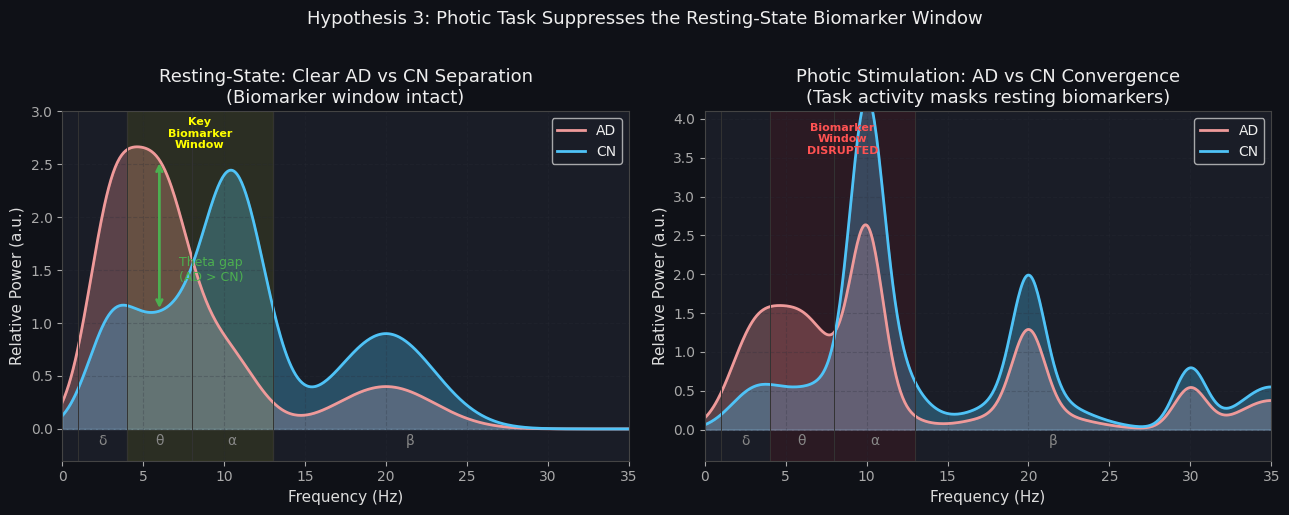

In [19]:
# ── Illustrate the biomarker window under two conditions ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

freqs = np.linspace(0, 40, 600)

def gaussian(f, center, width, amp):
    return amp * np.exp(-((f - center)**2) / (2 * width**2))

# ── Left: Resting-state (Static) — clear separation ───────────
ax = axes[0]

# AD resting-state: high theta, low alpha
ad_rest  = (gaussian(freqs, 3,  1.5, 1.8) +   # delta
            gaussian(freqs, 6,  1.8, 2.2) +   # theta elevated
            gaussian(freqs, 10, 2.0, 0.7) +   # alpha suppressed
            gaussian(freqs, 20, 3.0, 0.4))    # beta

# CN resting-state: dominant alpha, lower theta
cn_rest  = (gaussian(freqs, 3,  1.5, 0.9) +   # delta
            gaussian(freqs, 6,  1.8, 0.8) +   # theta normal
            gaussian(freqs, 10.5,2.0,2.4) +   # alpha dominant
            gaussian(freqs, 20, 3.0, 0.9))    # beta

ax.fill_between(freqs, ad_rest, alpha=0.3, color=COLORS["photic"])
ax.fill_between(freqs, cn_rest, alpha=0.3, color=COLORS["static"])
ax.plot(freqs, ad_rest, color=COLORS["photic"], lw=2, label="AD")
ax.plot(freqs, cn_rest, color=COLORS["static"], lw=2, label="CN")

# Shade the discriminative biomarker band
ax.axvspan(4, 13, alpha=0.08, color="yellow")
ax.text(8.5, 2.65, "Key\nBiomarker\nWindow", ha="center",
        fontsize=8, color="yellow", fontweight="bold")

# Annotate the theta gap
ax.annotate("", xy=(6, ad_rest[np.argmin(np.abs(freqs-6))]),
            xytext=(6, cn_rest[np.argmin(np.abs(freqs-6))]),
            arrowprops=dict(arrowstyle="<->", color="#4caf50", lw=2))
ax.text(7.2, 1.4, "Theta gap\n(AD > CN)", color="#4caf50", fontsize=9)

for band, (lo, hi, lbl) in [("δ",(1,4,"δ")), ("θ",(4,8,"θ")),
                              ("α",(8,13,"α")), ("β",(13,30,"β"))]:
    ax.text((lo+hi)/2, -0.15, lbl, ha="center", fontsize=10, color="#888")
    ax.axvline(lo, color="#333", lw=0.7)

ax.set_xlim(0, 35); ax.set_ylim(-0.3, 3.0)
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Relative Power (a.u.)")
ax.set_title("Resting-State: Clear AD vs CN Separation\n(Biomarker window intact)")
ax.legend(); ax.grid(alpha=0.25)

# ── Right: Photic condition — biomarker window disrupted ───────
ax2 = axes[1]

# Add task-induced components to both groups
task_component = (gaussian(freqs, 10, 1.0, 2.8) +   # SSVEP at 10 Hz
                  gaussian(freqs, 20, 1.0, 1.4) +   # 2nd harmonic
                  gaussian(freqs, 30, 1.0, 0.7) +   # 3rd harmonic
                  gaussian(freqs, 35, 2.0, 0.5))    # gamma burst

ad_photic = ad_rest * 0.6 + task_component * 0.75   # AD responds less to photic
cn_photic = cn_rest * 0.5 + task_component * 1.1    # CN responds strongly

ax2.fill_between(freqs, ad_photic, alpha=0.3, color=COLORS["photic"])
ax2.fill_between(freqs, cn_photic, alpha=0.3, color=COLORS["static"])
ax2.plot(freqs, ad_photic, color=COLORS["photic"], lw=2, label="AD")
ax2.plot(freqs, cn_photic, color=COLORS["static"], lw=2, label="CN")

# Shade the now-disrupted biomarker band
ax2.axvspan(4, 13, alpha=0.08, color="red")
ax2.text(8.5, 3.55, "Biomarker\nWindow\nDISRUPTED", ha="center",
         fontsize=8, color="#ff5252", fontweight="bold")

# Mark SSVEP peak
ax2.annotate("SSVEP\n10 Hz", xy=(10, cn_photic[np.argmin(np.abs(freqs-10))]),
             xytext=(14, 3.2),
             arrowprops=dict(arrowstyle="-|>", color=COLORS["both"], lw=1.5),
             color=COLORS["both"], fontsize=9, fontweight="bold")

for band, (lo, hi, lbl) in [("δ",(1,4,"δ")), ("θ",(4,8,"θ")),
                              ("α",(8,13,"α")), ("β",(13,30,"β"))]:
    ax2.text((lo+hi)/2, -0.2, lbl, ha="center", fontsize=10, color="#888")
    ax2.axvline(lo, color="#333", lw=0.7)

ax2.set_xlim(0, 35); ax2.set_ylim(-0.4, 4.1)
ax2.set_xlabel("Frequency (Hz)"); ax2.set_ylabel("Relative Power (a.u.)")
ax2.set_title("Photic Stimulation: AD vs CN Convergence\n(Task activity masks resting biomarkers)")
ax2.legend(); ax2.grid(alpha=0.25)

fig.suptitle("Hypothesis 3: Photic Task Suppresses the Resting-State Biomarker Window",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("../results/figures/fig6_hypothesis3_biomarkers.png", dpi=150, bbox_inches="tight")
plt.show()
